# 批量規範化
:label:`sec_batch_norm`

訓練深層神經網路是十分困難的，特別是在較短的時間內使他們收斂更加棘手。
本節將介紹*批量規範化*（batch normalization） :cite:`Ioffe.Szegedy.2015`，這是一種流行且有效的技術，可持續加速深層網路的收斂速度。
再結合在 :numref:`sec_resnet`中將介紹的殘差塊，批量規範化使得研究人員能夠訓練100層以上的網路。

## 訓練深層網路

為什麼需要批量規範化層呢？讓我們來回顧一下訓練神經網路時出現的一些實際挑戰。

首先，數據預處理的方式通常會對最終結果產生巨大影響。
回想一下我們應用多層感知機來預測房價的例子（ :numref:`sec_kaggle_house`）。
使用真實數據時，我們的第一步是標準化輸入特徵，使其平均值為0，方差為1。
直觀地說，這種標準化可以很好地與我們的優化器配合使用，因為它可以將參數的量級進行統一。

第二，對於典型的多層感知機或卷積神經網路。當我們訓練時，中間層中的變量（例如，多層感知機中的仿射變換輸出）可能具有更廣的變化範圍：不論是沿著從輸入到輸出的層，跨同一層中的單元，或是隨著時間的推移，模型參數的隨訓練更新變幻莫測。
批量規範化的發明者非正式地假設，這些變量分布中的這種偏移可能會阻礙網路的收斂。
直觀地說，我們可能會猜想，如果一個層的可變值是另一層的100倍，這可能需要對學習率進行補償調整。

第三，更深層的網路很複雜，容易過擬合。
這意味著正則化變得更加重要。

批量規範化應用於單個可選層（也可以應用到所有層），其原理如下：在每次訓練迭代中，我們首先規範化輸入，即通過減去其均值並除以其標準差，其中兩者均基於當前小批量處理。
接下來，我們應用比例係數和比例偏移。
正是由於這個基於*批量*統計的*標準化*，才有了*批量規範化*的命名。

請注意，如果我們嘗試使用大小為1的小批量應用批量規範化，我們將無法學到任何東西。
這是因為在減去均值之後，每個隱藏單元將為0。
所以，只有使用足夠大的小批量，批量規範化這種方法才是有效且穩定的。
請注意，在應用批量規範化時，批量大小的選擇可能比沒有批量規範化時更重要。

從形式上來說，用$\mathbf{x} \in \mathcal{B}$表示一個來自小批量$\mathcal{B}$的輸入，批量規範化$\mathrm{BN}$根據以下表達式轉換$\mathbf{x}$：

$$\mathrm{BN}(\mathbf{x}) = \boldsymbol{\gamma} \odot \frac{\mathbf{x} - \hat{\boldsymbol{\mu}}_\mathcal{B}}{\hat{\boldsymbol{\sigma}}_\mathcal{B}} + \boldsymbol{\beta}.$$
:eqlabel:`eq_batchnorm`

在 :eqref:`eq_batchnorm`中，$\hat{\boldsymbol{\mu}}_\mathcal{B}$是小批量$\mathcal{B}$的樣本均值，$\hat{\boldsymbol{\sigma}}_\mathcal{B}$是小批量$\mathcal{B}$的樣本標準差。
應用標準化後，生成的小批量的平均值為0和單位方差為1。
由於單位方差（以及其他一些魔法數）是一個主觀的選擇，因此我們通常包含
*拉伸參數*（scale）$\boldsymbol{\gamma}$和*偏移參數*（shift）$\boldsymbol{\beta}$，它們的形狀與$\mathbf{x}$相同。
請注意，$\boldsymbol{\gamma}$和$\boldsymbol{\beta}$是需要與其他模型參數一起學習的參數。

由於在訓練過程中，中間層的變化幅度不能過於劇烈，而批量規範化將每一層主動居中，並將它們重新調整為給定的平均值和大小（通過$\hat{\boldsymbol{\mu}}_\mathcal{B}$和${\hat{\boldsymbol{\sigma}}_\mathcal{B}}$）。

從形式上來看，我們計算出 :eqref:`eq_batchnorm`中的$\hat{\boldsymbol{\mu}}_\mathcal{B}$和${\hat{\boldsymbol{\sigma}}_\mathcal{B}}$，如下所示：

$$\begin{aligned} \hat{\boldsymbol{\mu}}_\mathcal{B} &= \frac{1}{|\mathcal{B}|} \sum_{\mathbf{x} \in \mathcal{B}} \mathbf{x},\\
\hat{\boldsymbol{\sigma}}_\mathcal{B}^2 &= \frac{1}{|\mathcal{B}|} \sum_{\mathbf{x} \in \mathcal{B}} (\mathbf{x} - \hat{\boldsymbol{\mu}}_{\mathcal{B}})^2 + \epsilon.\end{aligned}$$

請注意，我們在方差估計值中添加一個小的常量$\epsilon > 0$，以確保我們永遠不會嘗試除以零，即使在經驗方差估計值可能消失的情況下也是如此。估計值$\hat{\boldsymbol{\mu}}_\mathcal{B}$和${\hat{\boldsymbol{\sigma}}_\mathcal{B}}$通過使用平均值和方差的噪聲（noise）估計來抵消縮放問題。
乍看起來，這種噪聲是一個問題，而事實上它是有益的。

事實證明，這是深度學習中一個反覆出現的主題。
由於尚未在理論上明確的原因，優化中的各種噪聲源通常會導致更快的訓練和較少的過擬合：這種變化似乎是正則化的一種形式。
在一些初步研究中， :cite:`Teye.Azizpour.Smith.2018`和 :cite:`Luo.Wang.Shao.ea.2018`分別將批量規範化的性質與貝葉斯先驗相關聯。
這些理論揭示了為什麼批量規範化最適應$50 \sim 100$範圍中的中等批量大小的難題。

另外，批量規範化層在”訓練模式“（通過小批量統計數據規範化）和“預測模式”（通過數據集統計規範化）中的功能不同。
在訓練過程中，我們無法得知使用整個數據集來估計平均值和方差，所以只能根據每個小批次的平均值和方差不斷訓練模型。
而在預測模式下，可以根據整個數據集精確計算批量規範化所需的平均值和方差。

現在，我們了解一下批量規範化在實踐中是如何工作的。

## 批量規範化層

回想一下，批量規範化和其他層之間的一個關鍵區別是，由於批量規範化在完整的小批量上運行，因此我們不能像以前在引入其他層時那樣忽略批量大小。
我們在下面討論這兩種情況：全連接層和卷積層，他們的批量規範化實現略有不同。

### 全連接層

通常，我們將批量規範化層置於全連接層中的仿射變換和激活函數之間。
設全連接層的輸入為$\mathbf{x}$，權重參數和偏置參數分別為$\mathbf{W}$和$\mathbf{b}$，激活函數為$\phi$，批量規範化的運算符為$\mathrm{BN}$。
那麼，使用批量規範化的全連接層的輸出的計算詳情如下：

$$\mathbf{h} = \phi(\mathrm{BN}(\mathbf{W}\mathbf{x} + \mathbf{b}) ).$$

回想一下，均值和方差是在應用變換的"相同"小批量上計算的。

### 卷積層

同樣，對於卷積層，我們可以在卷積層之後和非線性激活函數之前應用批量規範化。
當卷積有多个輸出通道時，我們需要對這些通道的“每個”輸出執行批量規範化，每個通道都有自己的拉伸（scale）和偏移（shift）參數，這兩個參數都是標量。
假設我們的小批量包含$m$個樣本，並且對於每個通道，卷積的輸出具有高度$p$和寬度$q$。
那麼對於卷積層，我們在每個輸出通道的$m \cdot p \cdot q$個元素上同時執行批量規範化。
因此，在計算平均值和方差時，我們會收集所有空間位置的值，然後在給定通道內應用相同的均值和方差，以便在每個空間位置對值進行規範化。

### 預測過程中的批量規範化

正如我們前面提到的，批量規範化在訓練模式和預測模式下的行為通常不同。
首先，將訓練好的模型用於預測時，我們不再需要樣本均值中的噪聲以及在微批次上估計每個小批次產生的樣本方差了。
其次，例如，我們可能需要使用我們的模型對逐個樣本進行預測。
一種常用的方法是通过移动平均估算整个训练数据集的样本均值和方差，并在预测时使用它们得到确定的输出。
可見，和暫退法一樣，批量規範化層在訓練模式和預測模式下的計算結果也是不一樣的。

## (**從零實現**)

下面，我們從頭開始實現一個具有張量的批量規範化層。


In [1]:
import torch
from torch import nn



def batch_norm(X, gamma, beta, moving_mean, moving_var, eps, momentum):
    # 通過is_grad_enabled來判斷當前模式是訓練模式還是預測模式
    if not torch.is_grad_enabled():
        # 如果是在預測模式下，直接使用傳入的移動平均所得的均值和方差
        X_hat = (X - moving_mean) / torch.sqrt(moving_var + eps)
    else:
        assert len(X.shape) in (2, 4)
        if len(X.shape) == 2:
            # 使用全連接層的情況，計算特徵維上的均值和方差
            mean = X.mean(dim=0)
            var = ((X - mean) ** 2).mean(dim=0)
        else:
            # 使用二維卷積層的情況，計算通道維上（axis=1）的均值和方差。
            # 這裡我們需要保持X的形狀以便後面可以做廣播運算
            mean = X.mean(dim=(0, 2, 3), keepdim=True)
            var = ((X - mean) ** 2).mean(dim=(0, 2, 3), keepdim=True)
        # 訓練模式下，用當前的均值和方差做標準化
        X_hat = (X - mean) / torch.sqrt(var + eps)
        # 更新移動平均的均值和方差
        moving_mean = momentum * moving_mean + (1.0 - momentum) * mean
        moving_var = momentum * moving_var + (1.0 - momentum) * var
    Y = gamma * X_hat + beta  # 縮放和移位
    return Y, moving_mean.data, moving_var.data

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


我们现在可以[**創建一個正確的`BatchNorm`層**]。
這個層將保持適當的參數：拉伸`gamma`和偏移`beta`,這兩個參數將在訓練過程中更新。
此外，我們的層將保存均值和方差的移動平均值，以便在模型預測期間隨後使用。

撇開算法細節，注意我們實現層的基礎設計模式。
通常情況下，我們用一個單獨的函數定義其數學原理，比如說`batch_norm`。
然後，我們將此功能集成到一個自定義層中，其代碼主要處理數據移動到訓練設備（如GPU）、分配和初始化任何必需的變量、跟踪移動平均線（此處為均值和方差）等問題。
為了方便起見，我們並不擔心在這裡自動推斷輸入形狀，因此我們需要指定整個特徵的數量。
不用擔心，深度學習框架中的批量規範化API將為我們解決上述問題，我們稍後將展示這一點。


In [2]:
class BatchNorm(nn.Module):
    # num_features：完全連接層的輸出數量或卷積層的輸出通道數。
    # num_dims：2表示完全連接層，4表示卷積層
    def __init__(self, num_features, num_dims):
        super().__init__()
        if num_dims == 2:
            shape = (1, num_features)
        else:
            shape = (1, num_features, 1, 1)
        # 參與求梯度和迭代的拉伸和偏移參數，分別初始化成1和0
        self.gamma = nn.Parameter(torch.ones(shape))
        self.beta = nn.Parameter(torch.zeros(shape))
        # 非模型參數的變量初始化為0和1
        self.moving_mean = torch.zeros(shape)
        self.moving_var = torch.ones(shape)

    def forward(self, X):
        # 如果X不在記憶體上，將moving_mean和moving_var
        # 複製到X所在顯存上
        if self.moving_mean.device != X.device:
            self.moving_mean = self.moving_mean.to(X.device)
            self.moving_var = self.moving_var.to(X.device)
        # 保存更新過的moving_mean和moving_var
        Y, self.moving_mean, self.moving_var = batch_norm(
            X, self.gamma, self.beta, self.moving_mean,
            self.moving_var, eps=1e-5, momentum=0.9)
        return Y

##  使用批量規範化層的 LeNet

為了更好理解如何[**應用`BatchNorm`**]，下面我們將其應用(**於LeNet模型**)（ :numref:`sec_lenet`）。
回想一下，批量規範化是在卷積層或全連接層之後、相應的激活函數之前應用的。


In [3]:
net = nn.Sequential(
    nn.Conv2d(1, 6, kernel_size=5), BatchNorm(6, num_dims=4), nn.Sigmoid(),
    nn.AvgPool2d(kernel_size=2, stride=2),
    nn.Conv2d(6, 16, kernel_size=5), BatchNorm(16, num_dims=4), nn.Sigmoid(),
    nn.AvgPool2d(kernel_size=2, stride=2), nn.Flatten(),
    nn.Linear(16*4*4, 120), BatchNorm(120, num_dims=2), nn.Sigmoid(),
    nn.Linear(120, 84), BatchNorm(84, num_dims=2), nn.Sigmoid(),
    nn.Linear(84, 10))

和以前一樣，我們將[**在Fashion-MNIST數據集上訓練網路**]。
這個代碼與我們第一次訓練LeNet（ :numref:`sec_lenet`）時幾乎完全相同，主要區別在於學習率大得多。


Using device: mps


Epoch 1/10:   0%|          | 0/235 [00:00<?, ?it/s]

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


Epoch 1/10: 100%|██████████| 235/235 [00:21<00:00, 11.05it/s, loss=0.003, acc=70.39%]


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


...

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


Epoch 10/10:   0%|          | 0/235 [00:00<?, ?it/s]

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


Epoch 10/10: 100%|██████████| 235/235 [00:12<00:00, 18.74it/s, loss=0.001, acc=89.72%]


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


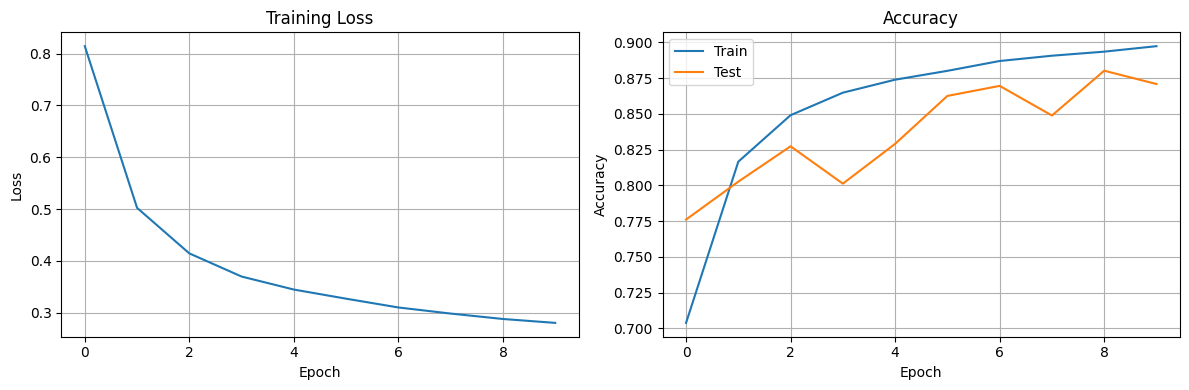


Final Results:
Final Loss: 0.2806
Final Train Accuracy: 0.8972
Final Test Accuracy: 0.8708
Average Epoch Time: 20.21s


In [4]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from tqdm import tqdm
import matplotlib.pyplot as plt
import time

class BatchNormLeNet(nn.Module):
    """帶有BatchNorm的LeNet"""
    def __init__(self):
        super(BatchNormLeNet, self).__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 6, kernel_size=5), 
            nn.BatchNorm2d(6),
            nn.Sigmoid(),
            nn.AvgPool2d(kernel_size=2, stride=2),
            
            nn.Conv2d(6, 16, kernel_size=5),
            nn.BatchNorm2d(16),
            nn.Sigmoid(),
            nn.AvgPool2d(kernel_size=2, stride=2),
            
            nn.Flatten(),
            
            nn.Linear(16*4*4, 120),
            nn.BatchNorm1d(120),
            nn.Sigmoid(),
            
            nn.Linear(120, 84),
            nn.BatchNorm1d(84),
            nn.Sigmoid(),
            
            nn.Linear(84, 10)
        )

    def forward(self, x):
        return self.net(x)

def load_fashion_mnist(batch_size, resize=None):
    """加載Fashion-MNIST數據集"""
    trans = [transforms.ToTensor()]
    if resize:
        trans.insert(0, transforms.Resize(resize))
    transform = transforms.Compose(trans)
    
    train_dataset = datasets.FashionMNIST(
        root='./data', 
        train=True, 
        download=True, 
        transform=transform
    )
    test_dataset = datasets.FashionMNIST(
        root='./data', 
        train=False, 
        download=True, 
        transform=transform
    )
    
    train_loader = DataLoader(
        train_dataset, 
        batch_size=batch_size, 
        shuffle=True, 
        num_workers=2
    )
    test_loader = DataLoader(
        test_dataset, 
        batch_size=batch_size, 
        shuffle=False, 
        num_workers=2
    )
    
    return train_loader, test_loader

def train_model(net, train_loader, test_loader, num_epochs, lr, device):
    """訓練模型"""
    net = net.to(device)
    optimizer = torch.optim.SGD(net.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    
    # 記錄訓練歷史
    history = {
        'train_loss': [],
        'train_acc': [],
        'test_acc': [],
        'epoch_times': []
    }
    
    for epoch in range(num_epochs):
        epoch_start = time.time()
        net.train()
        train_loss = 0
        correct_train = 0
        total_train = 0
        
        # 訓練階段
        train_bar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}')
        for inputs, targets in train_bar:
            inputs, targets = inputs.to(device), targets.to(device)
            
            optimizer.zero_grad()
            outputs = net(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            _, predicted = outputs.max(1)
            total_train += targets.size(0)
            correct_train += predicted.eq(targets).sum().item()
            
            # 更新進度條
            train_bar.set_postfix({
                'loss': f'{train_loss/total_train:.3f}',
                'acc': f'{100.*correct_train/total_train:.2f}%'
            })
        
        # 測試階段
        net.eval()
        correct_test = 0
        total_test = 0
        with torch.no_grad():
            for inputs, targets in test_loader:
                inputs, targets = inputs.to(device), targets.to(device)
                outputs = net(inputs)
                _, predicted = outputs.max(1)
                total_test += targets.size(0)
                correct_test += predicted.eq(targets).sum().item()
        
        # 計算並記錄結果
        epoch_time = time.time() - epoch_start
        epoch_loss = train_loss / len(train_loader)
        train_acc = correct_train / total_train
        test_acc = correct_test / total_test
        
        history['train_loss'].append(epoch_loss)
        history['train_acc'].append(train_acc)
        history['test_acc'].append(test_acc)
        history['epoch_times'].append(epoch_time)
        
        print(f'\nEpoch {epoch+1}/{num_epochs}:')
        print(f'Loss: {epoch_loss:.4f}')
        print(f'Train Acc: {train_acc:.4f}')
        print(f'Test Acc: {test_acc:.4f}')
        print(f'Time: {epoch_time:.2f}s')
        print('-' * 50)
    
    # 繪製訓練曲線
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'])
    plt.title('Training Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(True)
    
    plt.subplot(1, 2, 2)
    plt.plot(history['train_acc'], label='Train')
    plt.plot(history['test_acc'], label='Test')
    plt.title('Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()
    
    return history

if __name__ == "__main__":
    # 設置參數
    batch_size = 256
    num_epochs = 10
    lr = 1.0
    device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
    print(f"Using device: {device}")
    
    # 加載數據
    train_loader, test_loader = load_fashion_mnist(batch_size)
    
    # 創建模型
    net = BatchNormLeNet()
    
    # 訓練模型
    history = train_model(net, train_loader, test_loader, num_epochs, lr, device)
    
    # 打印最終結果
    print("\nFinal Results:")
    print(f"Final Loss: {history['train_loss'][-1]:.4f}")
    print(f"Final Train Accuracy: {history['train_acc'][-1]:.4f}")
    print(f"Final Test Accuracy: {history['test_acc'][-1]:.4f}")
    print(f"Average Epoch Time: {sum(history['epoch_times'])/len(history['epoch_times']):.2f}s")

讓我們來看看從第一個批量規範化層中學到的[**拉伸參數`gamma`和偏移參數`beta`**]。


In [8]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from tqdm import tqdm
def print_bn_params(net):
    """打印所有BatchNorm層的gamma和beta參數"""
    # 第一個BatchNorm層
    print("First BatchNorm layer parameters:")
    print("gamma:", net.bn1.weight.reshape(-1,))  # gamma就是weight
    print("beta:", net.bn1.bias.reshape(-1,))     # beta就是bias
    
    # 第二個BatchNorm層
    print("\nSecond BatchNorm layer parameters:")
    print("gamma:", net.bn2.weight.reshape(-1,))
    print("beta:", net.bn2.bias.reshape(-1,))
    
    # 第三個BatchNorm層
    print("\nThird BatchNorm layer parameters:")
    print("gamma:", net.bn3.weight.reshape(-1,))
    print("beta:", net.bn3.bias.reshape(-1,))
    
    # 第四個BatchNorm層
    print("\nFourth BatchNorm layer parameters:")
    print("gamma:", net.bn4.weight.reshape(-1,))
    print("beta:", net.bn4.bias.reshape(-1,))
def load_fashion_mnist(batch_size):
    """加載Fashion-MNIST數據集"""
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])
    
    train_dataset = datasets.FashionMNIST('./data', train=True, transform=transform, download=True)
    test_dataset = datasets.FashionMNIST('./data', train=False, transform=transform, download=True)
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    
    return train_loader, test_loader

def train(net, train_loader, test_loader, num_epochs, lr, device):
    """訓練模型"""
    net = net.to(device)
    optimizer = torch.optim.SGD(net.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    
    for epoch in range(num_epochs):
        # 訓練階段
        net.train()
        train_loss = 0
        correct = total = 0
        
        for X, y in tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}'):
            X, y = X.to(device), y.to(device)
            
            optimizer.zero_grad()
            y_hat = net(X)
            loss = criterion(y_hat, y)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            _, predicted = y_hat.max(1)
            total += y.size(0)
            correct += predicted.eq(y).sum().item()
        
        # 測試階段
        net.eval()
        test_correct = test_total = 0
        with torch.no_grad():
            for X, y in test_loader:
                X, y = X.to(device), y.to(device)
                y_hat = net(X)
                _, predicted = y_hat.max(1)
                test_total += y.size(0)
                test_correct += predicted.eq(y).sum().item()
        
        # 打印結果
        print(f'\nEpoch {epoch+1}:')
        print(f'Loss: {train_loss/len(train_loader):.3f}')
        print(f'Train Acc: {100.*correct/total:.2f}%')
        print(f'Test Acc: {100.*test_correct/test_total:.2f}%')
        print('-' * 50)

# [你的BatchNormLeNet類和print_bn_params函數保持不變]

if __name__ == "__main__":
    # 設置參數
    batch_size = 256
    num_epochs = 10
    lr = 1.0
    device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
    print(f"Using device: {device}")
    
    # 加載數據
    train_loader, test_loader = load_fashion_mnist(batch_size)
    
    # 創建模型
    net = BatchNormLeNet()
    
    # 訓練模型
    train(net, train_loader, test_loader, num_epochs, lr, device)
    
    # 打印BatchNorm層的參數
    print("\nBatchNorm Parameters after training:")
    print_bn_params(net)

Using device: mps


Epoch 1/10: 100%|██████████| 235/235 [00:20<00:00, 11.39it/s]



Epoch 1:
Loss: 0.772
Train Acc: 72.03%
Test Acc: 70.92%
--------------------------------------------------


Epoch 2/10: 100%|██████████| 235/235 [00:20<00:00, 11.63it/s]



Epoch 2:
Loss: 0.475
Train Acc: 82.53%
Test Acc: 70.13%
--------------------------------------------------


...


Epoch 8:
Loss: 0.284
Train Acc: 89.55%
Test Acc: 82.96%
--------------------------------------------------


Epoch 9/10: 100%|██████████| 235/235 [00:19<00:00, 12.07it/s]



Epoch 9:
Loss: 0.275
Train Acc: 89.91%
Test Acc: 86.25%
--------------------------------------------------


Epoch 10/10: 100%|██████████| 235/235 [00:18<00:00, 12.41it/s]



Epoch 10:
Loss: 0.264
Train Acc: 90.23%
Test Acc: 87.45%
--------------------------------------------------

BatchNorm Parameters after training:
First BatchNorm layer parameters:
gamma: tensor([3.9079, 1.6720, 2.7055, 2.2835, 4.5744, 2.7737], device='mps:0',
       grad_fn=<ViewBackward0>)
beta: tensor([-4.0136, -1.5132, -1.0369,  0.9328, -2.5981, -0.0848], device='mps:0',
       grad_fn=<ViewBackward0>)

Second BatchNorm layer parameters:
gamma: tensor([2.2410, 1.4452, 2.0025, 2.1144, 1.8983, 1.7265, 1.6003, 2.1897, 1.5868,
        2.0915, 2.0258, 0.8519, 1.9457, 1.3707, 1.7420, 2.2829],
       device='mps:0', grad_fn=<ViewBackward0>)
beta: tensor([-0.1075,  0.3221,  0.1317,  1.0120, -0.9261, -0.4266,  0.1254, -0.1545,
         0.8789, -0.2997,  0.1702,  0.1948,  0.6258,  0.2071,  0.2009,  0.6216],
       device='mps:0', grad_fn=<ViewBackward0>)

Third BatchNorm layer parameters:
gamma: tensor([1.0397, 1.2820, 1.4500, 1.1720, 1.3533, 1.0347, 1.1060, 1.1141, 1.1762,
        1.2328, 1

## [**簡明實現**]

除了使用我們剛剛定義的`BatchNorm`，我們也可以直接使用深度學習框架中定義的`BatchNorm`。
該代碼看起來幾乎與我們上面的代碼相同。


In [9]:
net = nn.Sequential(
    nn.Conv2d(1, 6, kernel_size=5), nn.BatchNorm2d(6), nn.Sigmoid(),
    nn.AvgPool2d(kernel_size=2, stride=2),
    nn.Conv2d(6, 16, kernel_size=5), nn.BatchNorm2d(16), nn.Sigmoid(),
    nn.AvgPool2d(kernel_size=2, stride=2), nn.Flatten(),
    nn.Linear(256, 120), nn.BatchNorm1d(120), nn.Sigmoid(),
    nn.Linear(120, 84), nn.BatchNorm1d(84), nn.Sigmoid(),
    nn.Linear(84, 10))

下面，我們[**使用相同超參數來訓練模型**]。
請注意，通常高級API變體運行速度快得多，因為它的代碼已編譯為C++或CUDA，而我們的自定義代碼由Python實現。


In [10]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from tqdm import tqdm
import matplotlib.pyplot as plt

def load_fashion_mnist(batch_size):
    """加載Fashion-MNIST數據集"""
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])
    
    train_dataset = datasets.FashionMNIST('./data', train=True, transform=transform, download=True)
    test_dataset = datasets.FashionMNIST('./data', train=False, transform=transform, download=True)
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    
    return train_loader, test_loader

class BatchNormLeNet(nn.Module):
    """帶有BatchNorm的LeNet"""
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 6, 5), nn.BatchNorm2d(6), nn.Sigmoid(),
            nn.AvgPool2d(2, 2),
            nn.Conv2d(6, 16, 5), nn.BatchNorm2d(16), nn.Sigmoid(),
            nn.AvgPool2d(2, 2),
            nn.Flatten(),
            nn.Linear(16*4*4, 120), nn.BatchNorm1d(120), nn.Sigmoid(),
            nn.Linear(120, 84), nn.BatchNorm1d(84), nn.Sigmoid(),
            nn.Linear(84, 10)
        )

    def forward(self, x):
        return self.net(x)

def train(net, train_loader, test_loader, num_epochs, lr, device):
    """訓練模型"""
    net = net.to(device)
    optimizer = torch.optim.SGD(net.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    
    for epoch in range(num_epochs):
        # 訓練階段
        net.train()
        train_loss = 0
        correct = total = 0
        
        for X, y in tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}'):
            X, y = X.to(device), y.to(device)
            
            optimizer.zero_grad()
            y_hat = net(X)
            loss = criterion(y_hat, y)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            _, predicted = y_hat.max(1)
            total += y.size(0)
            correct += predicted.eq(y).sum().item()
        
        # 測試階段
        net.eval()
        test_correct = test_total = 0
        with torch.no_grad():
            for X, y in test_loader:
                X, y = X.to(device), y.to(device)
                y_hat = net(X)
                _, predicted = y_hat.max(1)
                test_total += y.size(0)
                test_correct += predicted.eq(y).sum().item()
        
        # 打印結果
        print(f'\nEpoch {epoch+1}:')
        print(f'Loss: {train_loss/len(train_loader):.3f}')
        print(f'Train Acc: {100.*correct/total:.2f}%')
        print(f'Test Acc: {100.*test_correct/test_total:.2f}%')
        print('-' * 50)

if __name__ == '__main__':
    # 設置參數
    batch_size = 256
    num_epochs = 10
    lr = 1.0
    device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
    
    # 加載數據
    train_loader, test_loader = load_fashion_mnist(batch_size)
    
    # 創建和訓練模型
    net = BatchNormLeNet()
    train(net, train_loader, test_loader, num_epochs, lr, device)

Epoch 1/10: 100%|██████████| 235/235 [00:18<00:00, 12.48it/s]



Epoch 1:
Loss: 0.806
Train Acc: 70.38%
Test Acc: 63.07%
--------------------------------------------------


Epoch 2/10: 100%|██████████| 235/235 [00:17<00:00, 13.11it/s]



Epoch 2:
Loss: 0.512
Train Acc: 80.97%
Test Acc: 80.18%
--------------------------------------------------


Epoch 3/10: 100%|██████████| 235/235 [00:19<00:00, 12.20it/s]


...


Epoch 8:
Loss: 0.306
Train Acc: 88.72%
Test Acc: 85.11%
--------------------------------------------------


Epoch 9/10: 100%|██████████| 235/235 [00:19<00:00, 12.31it/s]



Epoch 9:
Loss: 0.295
Train Acc: 89.17%
Test Acc: 86.90%
--------------------------------------------------


Epoch 10/10: 100%|██████████| 235/235 [00:19<00:00, 12.06it/s]



Epoch 10:
Loss: 0.285
Train Acc: 89.53%
Test Acc: 86.56%
--------------------------------------------------


## 爭議

直觀地說，批量規範化被認為可以使優化更加平滑。
然而，我們必須小心區分直覺和對我們觀察到的現象的真實解釋。
回想一下，我們甚至不知道簡單的神經網路（多層感知機和傳統的卷積神經網路）為什麼如此有效。
即使在暫退法和權重衰減的情況下，它們仍然非常靈活，因此無法通過常規的學習理論泛化保證來解釋它們是否能夠泛化到看不見的數據。

在提出批量規範化的論文中，作者除了介紹了其應用，還解釋了其原理：通過減少*內部協變量偏移*（internal covariate shift）。
據推測，作者所說的*內部協變量轉移*類似於上述的投機直覺，即變量值的分布在訓練過程中會發生變化。
然而，這種解釋有兩個問題：
1、這種偏移與嚴格定義的*協變量偏移*（covariate shift）非常不同，所以這個名字用詞不當；
2、這種解釋只提供了一種不確定的直覺，但留下了一個有待後續挖掘的問題：為什麼這項技術如此有效？
本書旨在傳達實踐者用來發展深層神經網路的直覺。
然而，重要的是將這些指導性直覺與既定的科學事實區分開來。
最終，當你掌握了這些方法，並開始撰寫自己的研究論文時，你會希望清楚地區分技術和直覺。

隨著批量規範化的普及，*內部協變量偏移*的解釋反復出現在技術文獻的辯論中，特別是關於“如何展示機器學習研究”的更廣泛的討論中。
Ali Rahimi在接受2017年NeurIPS大會的“接受時間考驗獎”（Test of Time Award）時發表了一篇令人難忘的演講。
他將“內部協變量轉移”作為焦點，將現代深度學習的實踐比作煉金術。
他對該示例進行了詳細回顧 :cite:`Lipton.Steinhardt.2018`，概述了機器學習中令人不安的趨勢。
此外，一些作者對批量規範化的成功提出了另一種解釋：在某些方面，批量規範化的表現與原始論文 :cite:`Santurkar.Tsipras.Ilyas.ea.2018`中聲稱的行為是相反的。

然而，與機器學習文獻中成千上萬類似模糊的說法相比，內部協變量偏移沒有更值得批評。
很可能，它作為這些辯論的焦點而產生共鳴，要歸功於目標受眾對它的廣泛認可。
批量規範化已經被證明是一種不可或缺的方法。它適用於幾乎所有圖像分類器，並在學術界獲得了數萬引用。

## 小結

* 在模型訓練過程中，批量規範化利用小批量的均值和標準差，不斷調整神經網路的中間輸出，使整個神經網路各層的中間輸出值更加穩定。
* 批量規範化在全連接層和卷積層的使用略有不同。
* 批量規範化層和暫退層一樣，在訓練模式和預測模式下計算不同。
* 批量規範化有許多有益的副作用，主要是正則化。另一方面，”減少內部協變量偏移“的原始動機似乎不是一個有效的解釋。

## 練習

1. 在使用批量規範化之前，我們是否可以從全連接層或卷積層中刪除偏置參數？為什麼？
1. 比較LeNet在使用和不使用批量規範化情況下的學習率。
    1. 繪製訓練和測試準確度的提高。
    1. 學習率有多高？
1. 我們是否需要在每個層中進行批量規範化？嘗試一下？
1. 可以通過批量規範化來替換暫退法嗎？行為會如何改變？
1. 確定參數`beta`和`gamma`，並觀察和分析結果。
1. 查看高級API中關於`BatchNorm`的線上文檔，以查看其他批量規範化的應用。
1. 研究思路：可以應用的其他“規範化”轉換？可以應用概率積分轉換嗎？全秩協方差估計可以嗎？


[Discussions](https://discuss.d2l.ai/t/1874)
